In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

import pickle
import json
import sys
import numpy.random as random
sys.path.append("../../../")

import time 

from src.online_prediction import ContextAwareOnlinePredictor
from src.context_aware.models import createModel

ImportError: cannot import name 'smooth_timeseries_via_derivative' from 'src.context_aware.preprocessing.filter' (c:\Users\Ye\Documents\YuYeh_Documents\L2S\Projects\context_aware_traffic_predictor\experiments\notebooks\inference\../../..\src\context_aware\preprocessing\filter.py)

In [ ]:
rawDatasetFolder = "../../../data/raw"
configPath = "../../config/combined_flows_forward_40.json"
modelFolder = "../../../data/models/context_aware"
trafficDataFolder = "../../../data/processed/dpdr"
verbose = True

In [ ]:
config = json.load(open(configPath))
name = config.get("NAME")
len_window = config.get("LEN_WINDOW")
dim_data =  len(config.get("CONTEXT_IDXS"))

In [ ]:
csv_data = pd.read_csv(f"{trafficDataFolder}/{name}.csv")

with open(f"{modelFolder}/{name}_modelConfig.pkl", "rb") as f:
    modelConfig = pickle.load(f)
with open(f"{modelFolder}/{name}_metaConfig.pkl", "rb") as f:
    metaConfig = pickle.load(f)

metaConfig.display()

model, device = createModel(modelConfig)
model.load_checkpoint(f"{modelFolder}/{name}.pth")

MetaConfig:
  dim_data: 12
  window_length: 40
  history_length: 100
  smooth_fc: 1.5
  degree: 3
  Ts: 0.01
  min_vals: [-0.36894907  0.90292435 -0.38260963 -0.41950114  0.89724432 -0.50256594
 -0.44173692  0.89601395 -0.50351072 -0.37503843  0.99577361 -0.40302067]
  max_vals: [ 0.49172105  1.1641571  -0.03381354  0.52639037  1.1625885  -0.1044017
  0.52653422  1.13691496 -0.10175204  0.42422338  1.16192049 -0.034515  ]


In [ ]:
onlinePredictor = ContextAwareOnlinePredictor(model, metaConfig)

traffic_recieved_list = []
traffic_predicted_list = []

# Initialize timing based on CSV Time column
count = 0
N_count = 2000
base_csv_time = None
start_real_time = None
last_window_csv_time = None

while count < N_count:
    # Read current row
    csv_time = csv_data.iloc[count, 0]  # Time column
    transmission = csv_data.iloc[count, 1]  # Transmission Flags
    data_point = csv_data.iloc[count, 2:].values  # Payload data
    
    # Initialize base times on first row
    if base_csv_time is None:
        base_csv_time = csv_time
        start_real_time = time.time()
        last_window_csv_time = csv_time
    
    # ==================== transmitter timing ====================
    # Schedule based on CSV Time column (like sender.py)
    relative_seconds = csv_time - base_csv_time
    target_time = start_real_time + relative_seconds
    
    # Wait until target time
    while time.time() < target_time:
        time.sleep(0.001)  # Small sleep to avoid busy waiting
    
    count += 1
    
    # ==================== receiver ====================
    # Invoked upon receiving a new data point (only when transmission flag is 1)
    if int(transmission) == 1:
        onlinePredictor.receive(data_point)
    
    # Invoked every window_length * Ts seconds based on CSV time
    if (csv_time - last_window_csv_time) >= (metaConfig.window_length * metaConfig.Ts):
        last_window_csv_time = csv_time
        traffic_predicted, traffic_recieved = onlinePredictor.predict()
        traffic_predicted = np.round(traffic_predicted, 0).astype(int)
        traffic_recieved_list.append(traffic_recieved)
        traffic_predicted_list.append(traffic_predicted)

if verbose:
    print(f"Processed {count} rows")
    print(f"Generated {len(traffic_predicted_list)} predictions")
            
traffic_recieved_list = np.array(traffic_recieved_list).reshape(-1)
traffic_predicted_list = np.array(traffic_predicted_list).reshape(-1)

Processed 2000 rows
Generated 49 predictions


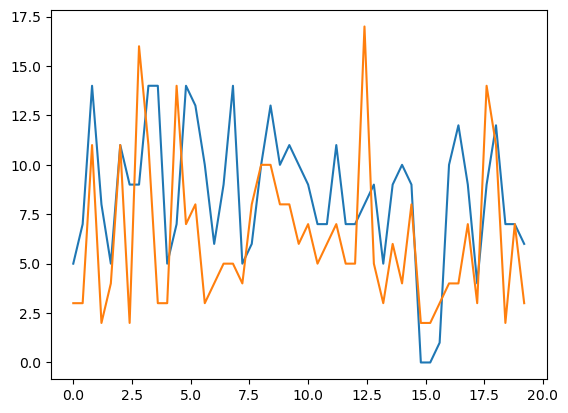

In [ ]:
N_display = min(200, len(traffic_recieved_list))
timestamp = np.arange(len(traffic_recieved_list)) * metaConfig.Ts * metaConfig.window_length
plt.plot(timestamp[:N_display], traffic_recieved_list[:N_display])
plt.plot(timestamp[:N_display], traffic_predicted_list[:N_display])
plt.show()